# **ספריות וקישור לדרייב**

In [ ]:
# יבוא ספריות והגדרות

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# חיבור לדרייב
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


# **נתיבים והגדרות**

In [ ]:
# --- הגדרת נתיבים חדשים (מצביעים לתיקייה המסודרת) ---
BASE_DIR = "/content/drive/MyDrive/Elbit Project/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **חלוקה לגנרטורים - אימון \ אימות**

In [ ]:
# גנרטור לאימון (עם אוגמנטציה)

# === הגדרת הגנרטורים והאוגמנטציה (Data Augmentation) ===
# המטרה: מניעת Overfitting (שינון) ע"י יצירת וריאציות של התמונות "תוך כדי תנועה" (On-the-fly).
# בכל Epoch, הגנרטור מחליף את התמונה המקורית בגרסה מעובדת, כך שהמודל לעולם לא רואה את אותה תמונה פעמיים בדיוק.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,           # עיוות מינימלי
    zoom_range=0.05,            # זום מינימלי למניעת חיתוך
    horizontal_flip=True,
    fill_mode='nearest'
)

# גנרטור לוולידציה (בלי אוגמנטציה, רק rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# טעינה
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, # נתיב ישיר לתיקיית ה-Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # כדי למנוע מהמודל ללמוד את סדר הנתונים ולהבטיח גיוון בכל באץ
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, # נתיב ישיר לתיקיית ה-Val
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"המחלקות שזוהו: {class_names}")

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
המחלקות שזוהו: ['Black&White', 'Cartoon', 'Good', 'Multiple', 'Noise or blur', 'Sketch', 'Text', 'Toys']


# **טעינת המודל מהקובץ ויישום FINE-TUNING + שמירה לקובץ חדש**

In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

# הגדרת נתיבים
PREV_MODEL_PATH = "/content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5"
FINETUNED_MODEL_PATH = "/content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16_finetuned.h5"

# פרמטרים ל-Fine Tuning (קצב למידה נמוך במיוחד)
FINE_TUNE_LR = 1e-5
EPOCHS_FT = 20

print("Loading the best model from Step 2...")
try:
    model = load_model(PREV_MODEL_PATH) # טעינת המודל VGG-16 לאחר ההתאמות מהקובץ
    print("Model loaded successfully.")
except OSError:
    print("Error: Could not find the model file.")

# הגדרת הקפאה/הפשרה של שכבות (Layer Freezing Logic)
# מכיוון שהמודל בנוי בצורה שטוחה, אעבור על כל השכבות ואגדיר ידנית
# אילו מהן פתוחות לאימון לפי השם שלהן.

print("Configuring layers for Fine-Tuning...")

for layer in model.layers:
    # 1. הקפאת הבלוקים הראשונים (Blocks 1-4)
    # אלו אחראים על זיהוי קווים ומרקמים בסיסיים, ואין צורך לשנותם.
    if layer.name.startswith(('block1', 'block2', 'block3', 'block4')):
        layer.trainable = False

    # 2. הפשרת הבלוק האחרון (Block 5)
    # זהו הבלוק שמזהה אובייקטים מורכבים. אני מפשיר אותו כדי להתאים
    # את הזיהוי ספציפית למחלקות המטוסים שלנו.
    elif layer.name.startswith('block5'):
        layer.trainable = True

    # 3. וידוא שהראש (השכבות שהוספנו: Dense, Prediction) נשאר פתוח
    elif layer.name in ['final_dense_layer', 'dropout', 'prediction']:
        layer.trainable = True

# בדיקה והדפסה של השכבות הפתוחות לאימון
# זהו שלב אימות קריטי לוודא שרק מה שרצינו אכן פתוח.
print("\nActive Trainable Layers:")
for layer in model.layers:
    # מדפיס רק שכבות שיש בהן משקולות (Weights) והן פתוחות ללמידה
    if layer.trainable and len(layer.weights) > 0:
        print(f"🔓 {layer.name}")

# קימפול מחדש של המודל (Re-compile)
# השימוש ב-Learning Rate נמוך (1e-5) הוא קריטי למניעת "שריפת" המשקולות בבלוק 5.
print(f"\nRe-compiling model with Learning Rate: {FINE_TUNE_LR}")
model.compile(optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# הגדרת Callbacks
checkpoint_ft = ModelCheckpoint(
    FINETUNED_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# הרצת האימון
print("Starting Fine-Tuning process...")
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    callbacks=[early_stop_ft, checkpoint_ft]
)

Loading the best model from Step 2...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Model loaded successfully.
Configuring layers for Fine-Tuning...

Active Trainable Layers:
🔓 block5_conv1
🔓 block5_conv2
🔓 block5_conv3
🔓 final_dense_layer
🔓 prediction

Re-compiling model with Learning Rate: 1e-05
Starting Fine-Tuning process...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.9439 - loss: 0.1880 
Epoch 1: val_accuracy improved from -inf to 0.91667, saving model to /content/drive/MyDrive/Amit Project/best_model_vgg16_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 694s 33s/step - accuracy: 0.9448 - loss: 0.1861 - val_accuracy: 0.9167 - val_loss: 0.3806
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.9868 - loss: 0.0869
Epoch 2: val_accuracy did not improve from 0.91667
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 803ms/step - accuracy: 0.9866 - loss: 0.0874 - val_accuracy: 0.9028 - val_loss: 0.3757
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9753 - loss: 0.0877
Epoch 3: val_accuracy did not improve from 0.91667
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 765ms/step - accuracy: 0.9755 - loss: 0.0873 - val_accuracy: 0.8542 - val_loss: 0.3954
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.9800 - loss: 0.0643
Epoch 4: val_accuracy did not improve from 0.91667
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 757ms/step - accuracy: 0.9797 - loss: 0.0648 - val_accuracy: 0.8889 - val_loss: 0.3502
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9774 - loss: 0.0807
Epoch 5: val_accuracy did not im

# **טעינת המודל מהקובץ**

In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16_finetuned.h5"

# --- מנגנון בטיחות: בודק אם כבר הרצנו את זה בעבר ---
if os.path.exists(model_path):
    model = load_model(model_path)
    print("המודל נטען בהצלחה!.")

else:
    print("נתיב לא נמצא! בדוק חיבור לדרייב, נתיב או הרץ את המודל מחדש")


המודל נטען בהצלחה!.


# **גרפי וויזואליזציה סופית**

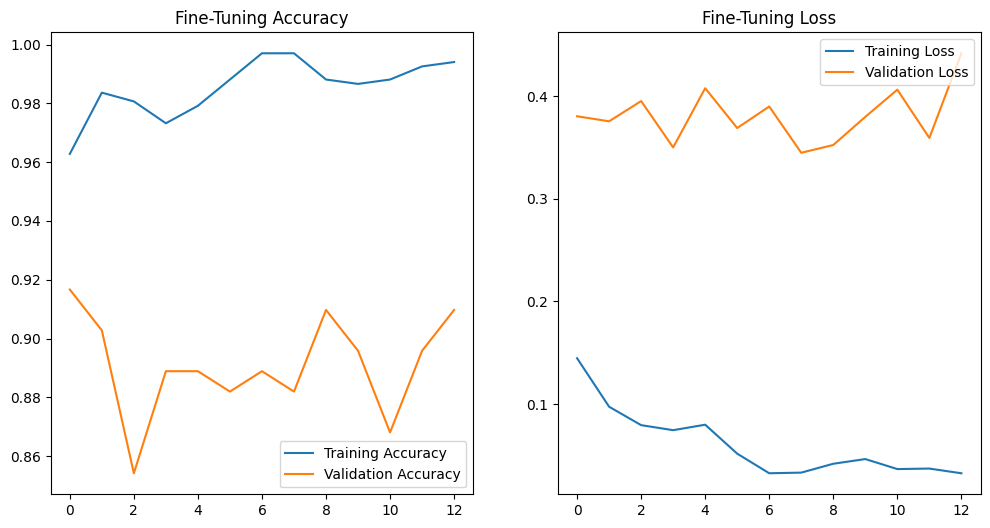

In [ ]:
# ויזואליזציה של תהליך ה-Fine Tuning
# מכיוון שמדובר בהמשך אימון, אנו מצפים לראות שיפור עדין ואיטי יותר
# מאשר בשלב האימון הראשוני.
acc = history_ft.history['accuracy']
val_acc = history_ft.history['val_accuracy']
loss = history_ft.history['loss']
val_loss = history_ft.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# גרף דיוק (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Fine-Tuning Accuracy')

# גרף שגיאה (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Fine-Tuning Loss')

plt.show()

# **הצגת מטריצות ואחוזי הצלחה**

מכין גנרטורים לבדיקה (Train + Val)...
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

מעבד תחזיות עבור: TRAIN Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 351ms/step


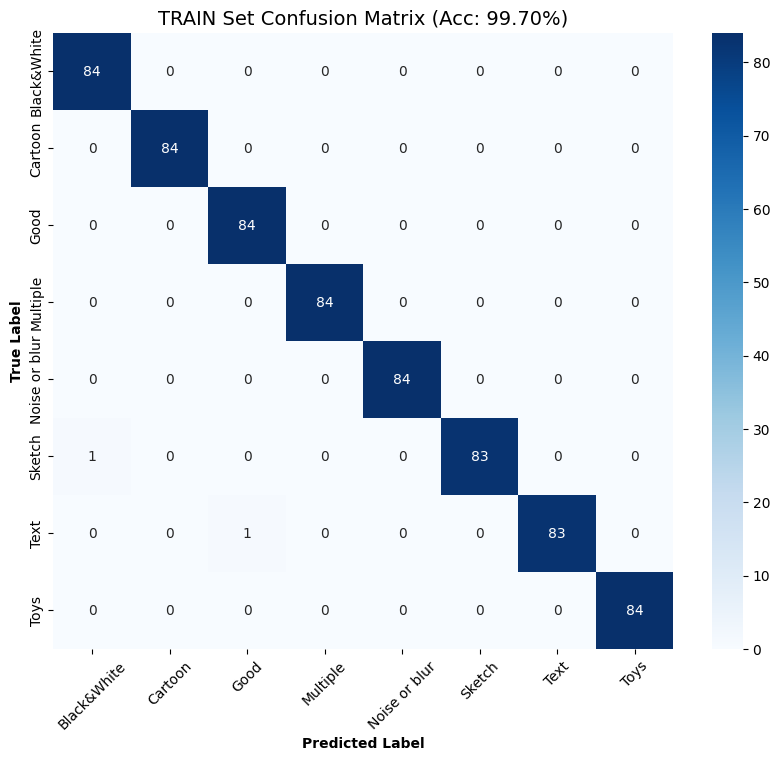


מעבד תחזיות עבור: VALIDATION Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step


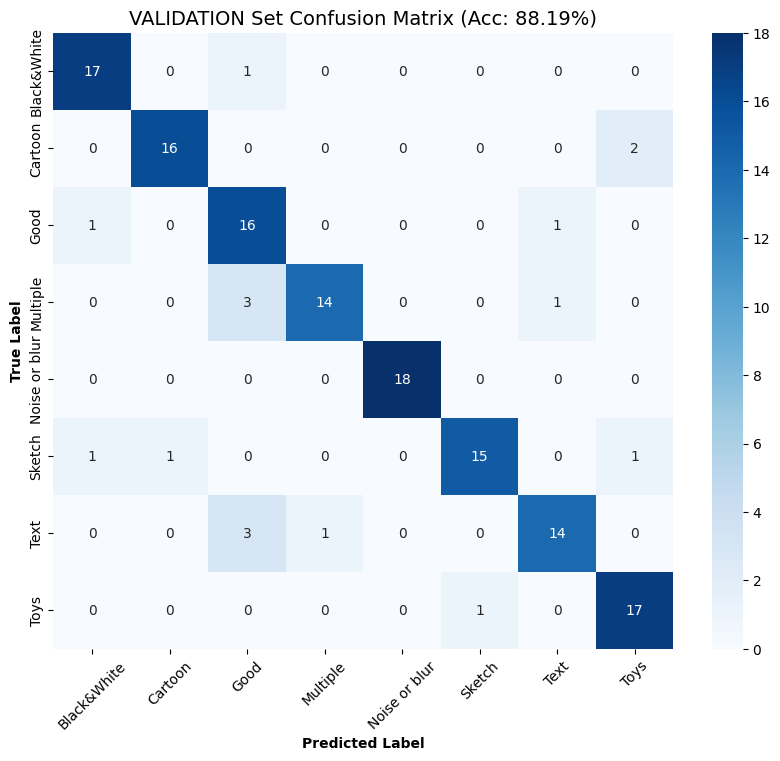


 מכין תצוגה ויזואלית של טעויות והצלחות...


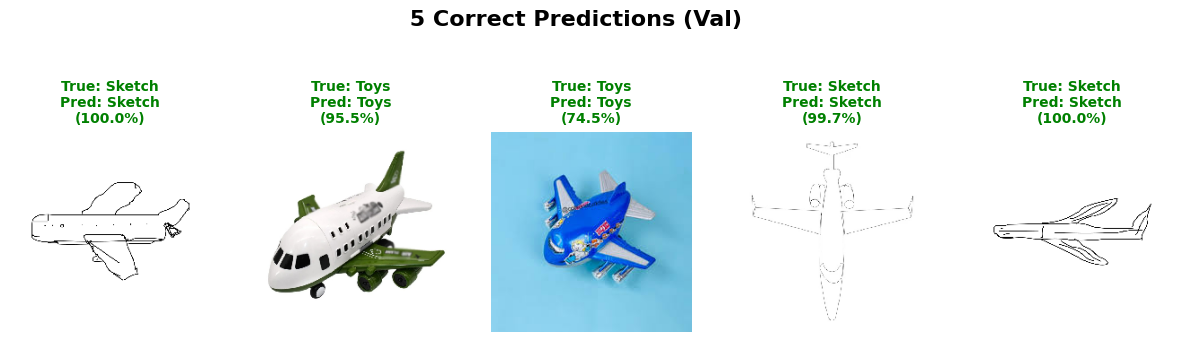

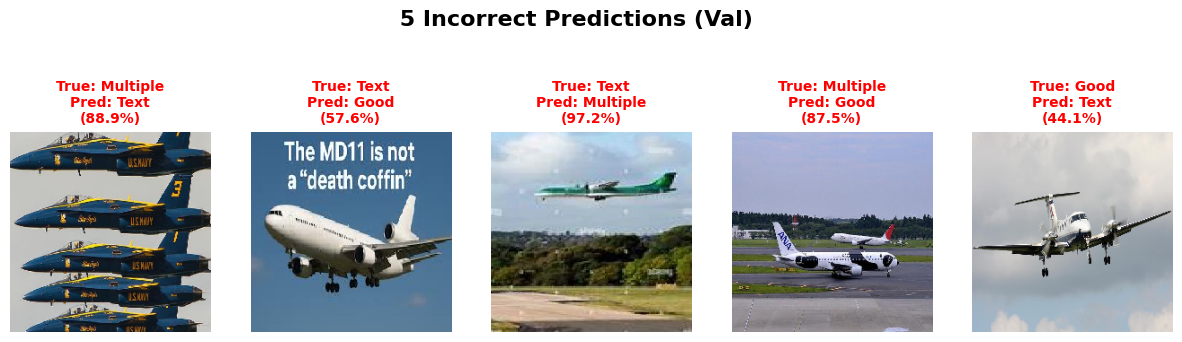

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. הכנת נתונים ללא ערבוב

print("מכין גנרטורים לבדיקה (Train + Val)...")

eval_datagen = ImageDataGenerator(rescale=1./255)

# גנרטור TRAIN (לבדיקת שינון)
train_gen_eval = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# גנרטור VAL (לבדיקת ביצועים)
val_gen_eval = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# שמות המחלקות
class_names = list(train_gen_eval.class_indices.keys())

# 2. פונקציה לחישוב והצגת מטריצה

def analyze_and_plot(generator, title_set):
    print(f"\nמעבד תחזיות עבור: {title_set}...")
    generator.reset()

    # חיזוי
    preds_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = generator.classes

    # חישוב מטריצה ודיוק
    cm = confusion_matrix(y_true, y_pred)
    acc = np.mean(y_true == y_pred)

    # ציור היט-מאפ (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title_set} Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

    # החזרת הנתונים כדי להשתמש בהם לתמונות
    return preds_probs, y_pred, y_true

# 3. הרצת הבדיקות (מטריצות)

# א. מטריצה ל-TRAIN
analyze_and_plot(train_gen_eval, "TRAIN Set")

# ב. מטריצה ל-VAL (שומרים את התוצאות להצגת התמונות)
val_probs, val_preds, val_true = analyze_and_plot(val_gen_eval, "VALIDATION Set")

# 4. הצגת תמונות (הצלחות vs כישלונות ב-VAL)

print("\n מכין תצוגה ויזואלית של טעויות והצלחות...")

# טעינת התמונות לזיכרון לתצוגה
val_images = []
val_gen_eval.reset()
for i in range(len(val_gen_eval)):
    batch_imgs, _ = next(val_gen_eval)
    val_images.extend(batch_imgs)
val_images = np.array(val_images)

# אינדקסים
correct_indices = np.where(val_preds == val_true)[0]
incorrect_indices = np.where(val_preds != val_true)[0]

def plot_images_grid(indices, title, is_error=False):
    if len(indices) == 0:
        print(f"אין תמונות להציג עבור: {title}")
        return

    n_show = min(5, len(indices))
    selected_indices = np.random.choice(indices, n_show, replace=False)

    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    for i, idx in enumerate(selected_indices):
        img = val_images[idx]
        true_lbl = class_names[val_true[idx]]
        pred_lbl = class_names[val_preds[idx]]
        conf = np.max(val_probs[idx]) * 100

        col = 'red' if is_error else 'green'

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\n({conf:.1f}%)", color=col, fontsize=10, fontweight='bold')
        plt.axis("off")
    plt.show()

# הצגה
plot_images_grid(correct_indices, " 5 Correct Predictions (Val)", is_error=False)

if len(incorrect_indices) > 0:
    plot_images_grid(incorrect_indices, " 5 Incorrect Predictions (Val)", is_error=True)
else:
    print("\n המודל צדק ב-100% מהמקרים ב-Validation.")

# **הערכת המודל על סט המבחן**

In [ ]:
# --- הגדרת גנרטור לטסט ---
test_datagen = ImageDataGenerator(rescale=1./255) # רק נרמול, בלי אוגמנטציה

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,  # הנתיב לתיקיית ה-test
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# --- ביצוע המבחן הסופי ---
print("\n מבצע הערכה על סט הטסט (Test Set)...")
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n דיוק סופי על הטסט: {test_acc*100:.2f}%")

Found 144 images belonging to 8 classes.

 מבצע הערכה על סט הטסט (Test Set)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 78s 19s/step - accuracy: 0.9253 - loss: 0.3321

 דיוק סופי על הטסט: 91.67%


נערך חיזוי על סט הטסט...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step


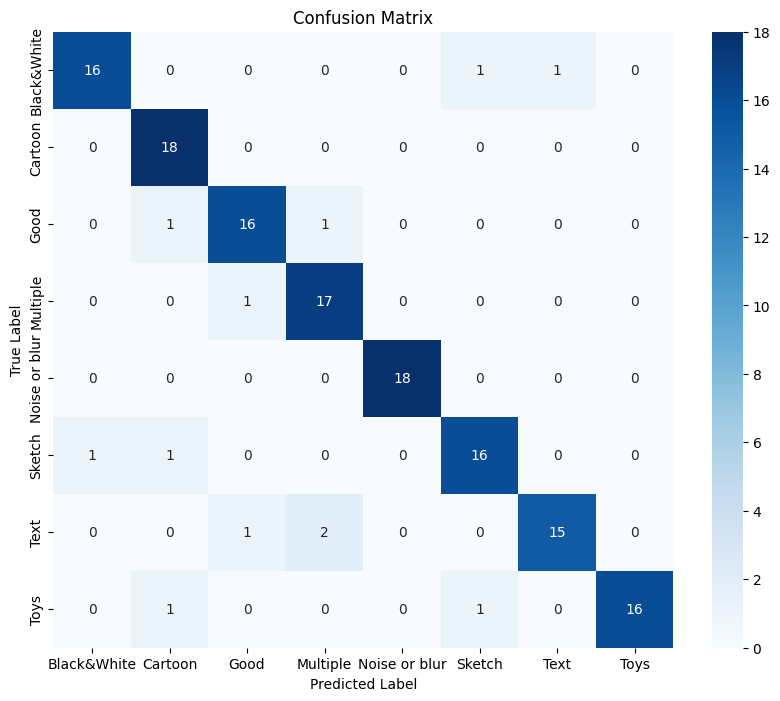


Classification Report:

               precision    recall  f1-score   support

  Black&White       0.94      0.89      0.91        18
      Cartoon       0.86      1.00      0.92        18
         Good       0.89      0.89      0.89        18
     Multiple       0.85      0.94      0.89        18
Noise or blur       1.00      1.00      1.00        18
       Sketch       0.89      0.89      0.89        18
         Text       0.94      0.83      0.88        18
         Toys       1.00      0.89      0.94        18

     accuracy                           0.92       144
    macro avg       0.92      0.92      0.92       144
 weighted avg       0.92      0.92      0.92       144



In [ ]:
# 1. ביצוע חיזוי על כל סט הטסט

print("נערך חיזוי על סט הטסט...")
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1) # הפיכת הסתברויות למספר מחלקה (0, 1, 2...)
y_true = test_gen.classes # התוויות האמיתיות

# 2. יצירת מטריצת הבלבול

cm = confusion_matrix(y_true, y_pred)

# 3. ציור הגרף

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. דוח טקסטואלי מפורט

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

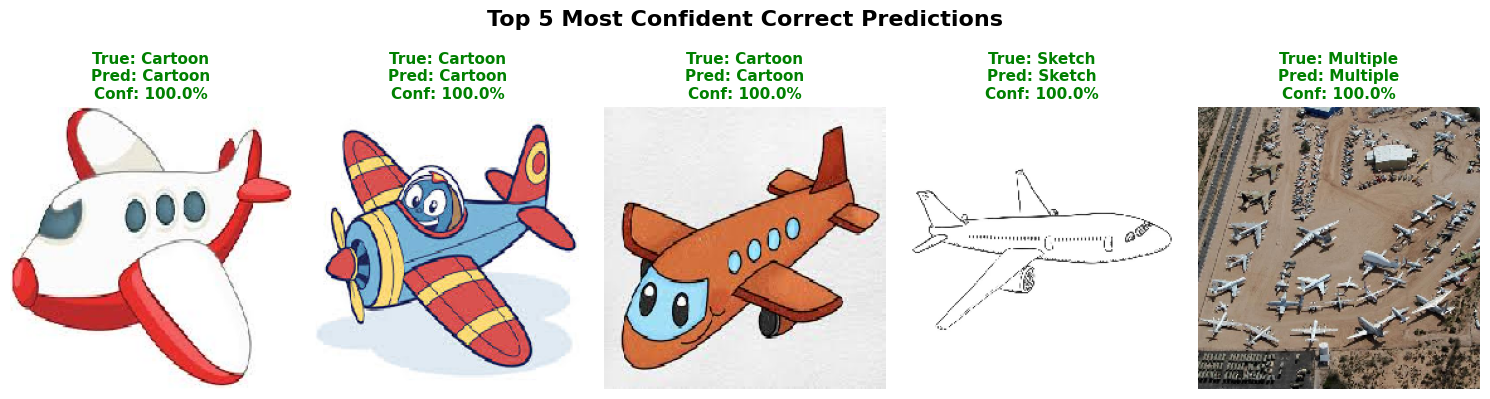

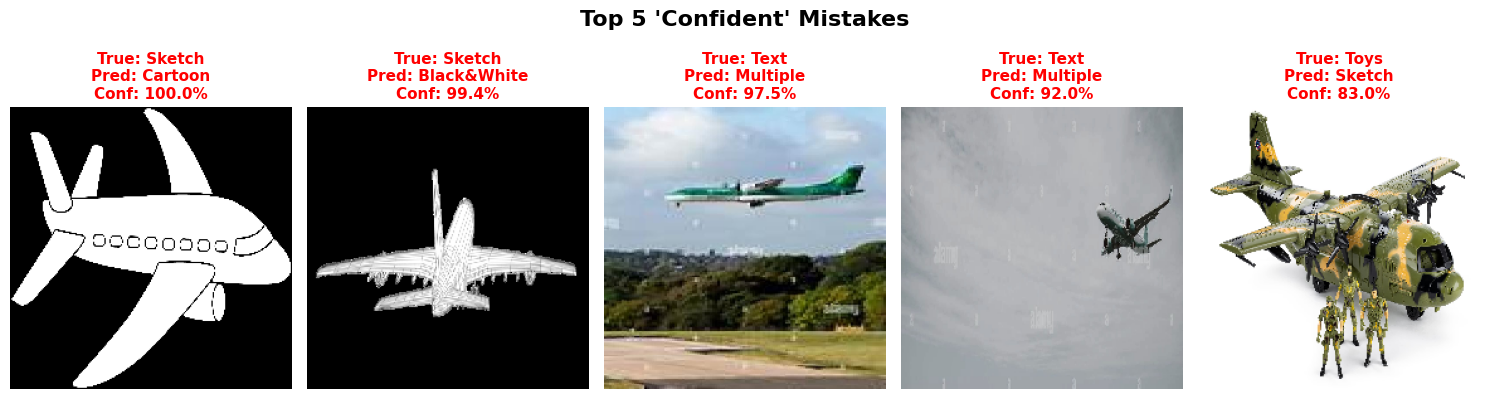

In [ ]:
from tensorflow.keras.preprocessing import image

# 5. הצגת הצלחות וכישלונות (ממוין לפי רמת ביטחון)

# שליפת רשימת הקבצים
file_paths = test_gen.filepaths

# מציאת אינדקסים
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# שליפת רמות הביטחון (Confidence) לכל התחזיות
confidences = np.max(y_pred_prob, axis=1)

def plot_sorted_predictions(indices, title, color, sort_descending=True):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    if len(indices) == 0:
        print(f"לא נמצאו דוגמאות עבור: {title}")
        return

    # שולפים את הביטחון רק עבור האינדקסים הרלוונטיים
    relevant_confidences = confidences[indices]

    # מיון האינדקסים (Argsort)
    if sort_descending:
        # מהגבוה לנמוך (הכי בטוחים)
        sorted_order = np.argsort(relevant_confidences)[::-1]
    else:
        # מהנמוך לגבוה (הכי פחות)
        sorted_order = np.argsort(relevant_confidences)

    # לוקחים את ה-5 הראשונים אחרי המיון
    top_n_indices = indices[sorted_order[:5]]

    for i, idx in enumerate(top_n_indices):
        img_path = file_paths[idx]
        img = image.load_img(img_path, target_size=(224, 224))

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                  color=color, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- הפעלת הפונקציות ---

# 1. ההצלחות הכי גדולות (הכי בטוח בעצמו)
plot_sorted_predictions(correct_indices, "Top 5 Most Confident Correct Predictions", 'green', sort_descending=True)

# 2. הטעויות הכי "קשות" (המודל היה בטוח שהוא צודק, אבל טעה)!
if len(incorrect_indices) > 0:
    plot_sorted_predictions(incorrect_indices, "Top 5 'Confident' Mistakes", 'red', sort_descending=True)
else:
    print("אין טעויות להציג.")

# **הרצת תמונות חדשות מהעולם**

In [ ]:
# קישור לתיקיית מקור
base_dir = "/content/drive/MyDrive/Elbit Project/Images Data for Coding"

# רשימה של זוגות: (שם קובץ, הלייבל האמיתי)
test_data = [
    ('test_image.jpg', 'Sketch'),
    ('test_image2.jpg', 'Noise or blur'),
    ('test_image3.jpg', 'Multiple'),
    ('test_image4.jpg', 'Multiple'),
    ('test_image5.png', 'Text')
]

#  לולאת עיבוד ותצוגה

plt.figure(figsize=(20, 6)) # רוחב גדול
print(" מציג תוצאות ויזואליות...\n")

for i, (file_name, true_label) in enumerate(test_data):
    full_path = os.path.join(base_dir, file_name)

    # 1. בדיקה שהקובץ קיים
    if not os.path.exists(full_path):
        continue

    # 2. טעינה ועיבוד
    img = image.load_img(full_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = img_batch / 255.0  # נירמול

    # 3. חיזוי
    probs = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]

    # 4. בדיקת פרדיקציה וקביעת צבע
    is_correct = (pred_label == true_label)
    title_color = 'green' if is_correct else 'red'

    # טקסט לכותרת (לייבל אמיתי לעומת מה המודל חשב)
    title_text = f"True: {true_label}\nPred: {pred_label}"

    # 5. הוספה לגרף
    plt.subplot(1, len(test_data), i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(title_text, fontsize=14, color=title_color, fontweight='bold')

# סידור והצגה
plt.tight_layout()
plt.show()

 מציג תוצאות ויזואליות...



<Figure size 2000x600 with 0 Axes>